In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Real_House_Data.csv")
df

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Renovation_Status,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,...,Property_Type,Construction_Quality_Rating,Energy_Efficiency_Score,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price
0,2684.821829,5,5,2,2018,7,Yes,3776.225833,33.354414,8,...,Independent House,2,NaN,4,5,8,51.585174,42.269855,51.872234,1.203248e+07
1,1772.507662,1,1,1,1970,55,No,3343.248191,21.896193,5,...,Apartment,5,5.0,3,5,8,36.729241,66.331214,66.489083,7.425842e+06
2,1655.959623,2,1,1,2015,10,No,2856.909759,25.358405,2,...,Apartment,8,2.0,3,5,10,20.020779,79.023068,68.119671,5.734560e+06
3,1655.979127,1,1,1,1976,49,Yes,2998.753552,22.062582,6,...,Apartment,5,10.0,9,2,4,40.894197,53.745498,60.449037,8.258959e+06
4,4879.446067,3,2,3,1999,26,No,5373.625371,22.449431,2,...,Villa,5,9.0,1,10,2,22.463846,86.873374,61.445164,2.128731e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,No,3766.541599,10.708116,9,...,Villa,9,3.0,7,6,2,72.799026,36.744778,43.506769,1.173157e+07
9996,1373.561786,3,3,2,1994,31,No,2271.349068,11.949866,4,...,Villa,3,10.0,9,3,8,25.805114,89.150722,66.396883,6.458641e+06
9997,1191.319333,2,2,2,2022,3,No,2748.265662,23.944225,2,...,Independent House,8,2.0,10,4,8,0.000000,91.177488,76.934267,4.891362e+06
9998,2811.384485,6,5,1,1970,55,No,NaN,7.170758,8,...,Villa,1,1.0,1,8,7,54.362379,47.010666,53.486149,1.353664e+07


In [3]:
df.isnull().sum()

Property_Area                       0
Bedrooms                            0
Bathrooms                           0
Floors                              0
Year_Built                          0
Property_Age                        0
Renovation_Status                   0
Lot_Size                          500
Distance_to_City_Center             0
Neighborhood_Quality_Score          0
Crime_Rate_Index                    0
Nearby_School_Rating              500
Hospital_Proximity_km               0
Shopping_Center_Proximity_km        0
Public_Transport_Accessibility      0
Parking_Availability                0
Property_Type                       0
Construction_Quality_Rating         0
Energy_Efficiency_Score           500
Water_Supply_Reliability            0
Electricity_Supply_Reliability      0
Internet_Availability_Score         0
Green_Space_Availability_Index    500
Flood_Risk_Index                    0
Noise_Pollution_Level               0
Price                               0
dtype: int64

In [4]:
#Lot_Size Fixed
df['Lot_Size'] = df.groupby(['Property_Type', 'Bedrooms'])['Lot_Size'].transform(lambda x: x.fillna(x.mean()))

In [5]:
#Nearby School Rating Fixed
df['Neighborhood_bin'] = pd.cut(df['Neighborhood_Quality_Score'], bins=5)

df['Nearby_School_Rating'] = df.groupby('Neighborhood_bin' , observed = True)['Nearby_School_Rating'].transform(
    lambda x: x.fillna(x.mean())
)

In [6]:
#Energy Score Fixed
df['Age_bin'] = pd.cut(df['Property_Age'], bins=5)

df['Energy_Efficiency_Score'] = df.groupby(['Age_bin', 'Construction_Quality_Rating'] , observed = True)['Energy_Efficiency_Score'].transform(
    lambda x: x.fillna(x.mean())
)

In [7]:
#Green Availability Fixed
df['Distance_bin'] = pd.cut(df['Distance_to_City_Center'], bins=5)

df['Green_Space_Availability_Index'] = df.groupby('Distance_bin' , observed = True)['Green_Space_Availability_Index'].transform(
    lambda x: x.fillna(x.mean())
)

In [8]:
print(df.isnull().sum())
df_new = df.drop(columns = ['Neighborhood_bin' , 'Age_bin' , 'Distance_bin'])
df_new

Property_Area                     0
Bedrooms                          0
Bathrooms                         0
Floors                            0
Year_Built                        0
Property_Age                      0
Renovation_Status                 0
Lot_Size                          0
Distance_to_City_Center           0
Neighborhood_Quality_Score        0
Crime_Rate_Index                  0
Nearby_School_Rating              0
Hospital_Proximity_km             0
Shopping_Center_Proximity_km      0
Public_Transport_Accessibility    0
Parking_Availability              0
Property_Type                     0
Construction_Quality_Rating       0
Energy_Efficiency_Score           0
Water_Supply_Reliability          0
Electricity_Supply_Reliability    0
Internet_Availability_Score       0
Green_Space_Availability_Index    0
Flood_Risk_Index                  0
Noise_Pollution_Level             0
Price                             0
Neighborhood_bin                  0
Age_bin                     

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Renovation_Status,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,...,Property_Type,Construction_Quality_Rating,Energy_Efficiency_Score,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price
0,2684.821829,5,5,2,2018,7,Yes,3776.225833,33.354414,8,...,Independent House,2,5.769608,4,5,8,51.585174,42.269855,51.872234,1.203248e+07
1,1772.507662,1,1,1,1970,55,No,3343.248191,21.896193,5,...,Apartment,5,5.000000,3,5,8,36.729241,66.331214,66.489083,7.425842e+06
2,1655.959623,2,1,1,2015,10,No,2856.909759,25.358405,2,...,Apartment,8,2.000000,3,5,10,20.020779,79.023068,68.119671,5.734560e+06
3,1655.979127,1,1,1,1976,49,Yes,2998.753552,22.062582,6,...,Apartment,5,10.000000,9,2,4,40.894197,53.745498,60.449037,8.258959e+06
4,4879.446067,3,2,3,1999,26,No,5373.625371,22.449431,2,...,Villa,5,9.000000,1,10,2,22.463846,86.873374,61.445164,2.128731e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,No,3766.541599,10.708116,9,...,Villa,9,3.000000,7,6,2,72.799026,36.744778,43.506769,1.173157e+07
9996,1373.561786,3,3,2,1994,31,No,2271.349068,11.949866,4,...,Villa,3,10.000000,9,3,8,25.805114,89.150722,66.396883,6.458641e+06
9997,1191.319333,2,2,2,2022,3,No,2748.265662,23.944225,2,...,Independent House,8,2.000000,10,4,8,0.000000,91.177488,76.934267,4.891362e+06
9998,2811.384485,6,5,1,1970,55,No,4906.370154,7.170758,8,...,Villa,1,1.000000,1,8,7,54.362379,47.010666,53.486149,1.353664e+07


In [9]:

# Basic info
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

   Property_Area  Bedrooms  Bathrooms  Floors  Year_Built  Property_Age  \
0    2684.821829         5          5       2        2018             7   
1    1772.507662         1          1       1        1970            55   
2    1655.959623         2          1       1        2015            10   
3    1655.979127         1          1       1        1976            49   
4    4879.446067         3          2       3        1999            26   

  Renovation_Status     Lot_Size  Distance_to_City_Center  \
0               Yes  3776.225833                33.354414   
1                No  3343.248191                21.896193   
2                No  2856.909759                25.358405   
3               Yes  2998.753552                22.062582   
4                No  5373.625371                22.449431   

   Neighborhood_Quality_Score  ...  Water_Supply_Reliability  \
0                           8  ...                         4   
1                           5  ...                    

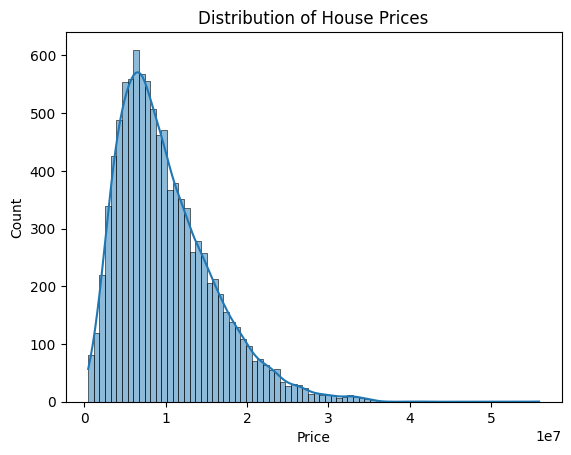

1.1047004945340464


In [10]:
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()
print(df["Price"].skew())

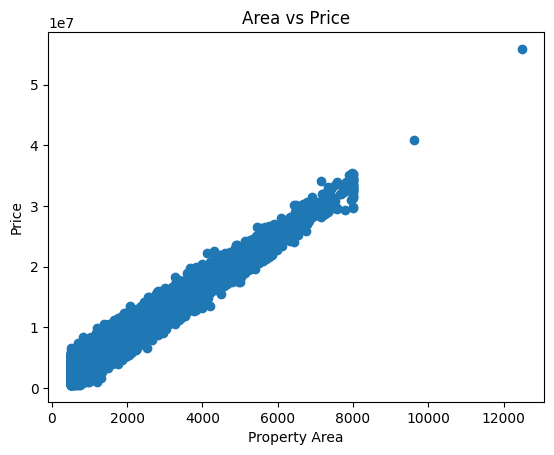

In [11]:
plt.scatter(df["Property_Area"], df["Price"])
plt.xlabel("Property Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

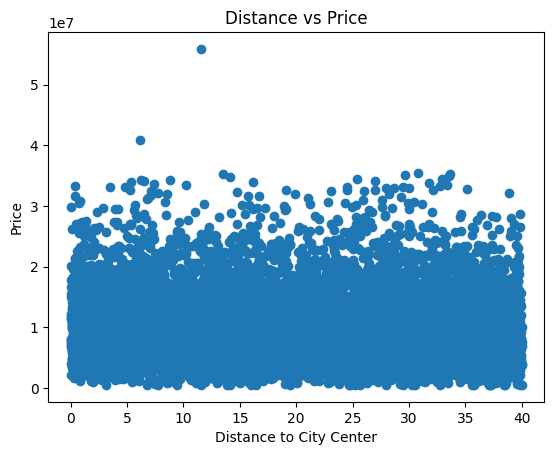

In [12]:
plt.scatter(df["Distance_to_City_Center"], df["Price"])
plt.xlabel("Distance to City Center")
plt.ylabel("Price")
plt.title("Distance vs Price")
plt.show()

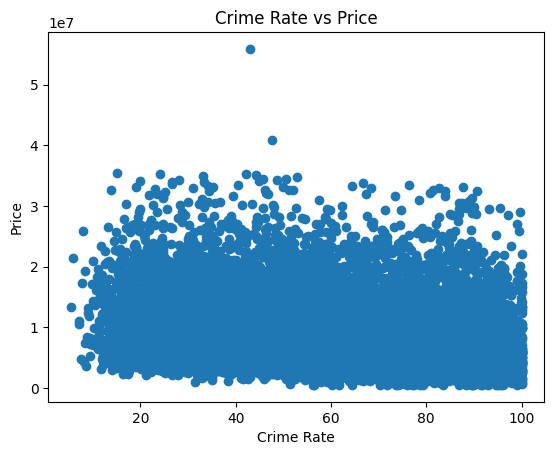

In [13]:
plt.scatter(df["Crime_Rate_Index"], df["Price"])
plt.xlabel("Crime Rate")
plt.ylabel("Price")
plt.title("Crime Rate vs Price")
plt.show()

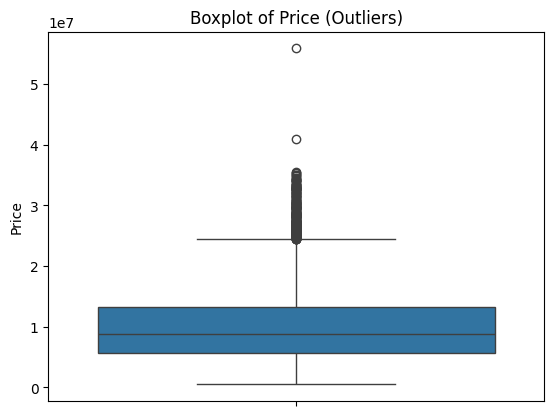

In [14]:
plt.figure()
sns.boxplot(df["Price"])
plt.title("Boxplot of Price (Outliers)")
plt.show()

In [15]:
#One-Hot Encoding Used 

cat_col = df_new.select_dtypes(include='object').columns
df_new = pd.get_dummies(df_new , columns = cat_col , drop_first = True)
#  drop-first Function takes 1 value of the categorical column as a 'reference'

df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
4,4879.446067,3,2,3,1999,26,5373.625371,22.449431,2,77.985565,...,1,10,2,22.463846,86.873374,61.445164,2.128731e+07,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
9996,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
9997,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
9998,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [16]:
num_cols = [col for col in df_new.columns if df_new[col].nunique() > 2]

for col in num_cols:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_new = df_new[(df_new[col] >= lower) & (df_new[col] <= upper)]

df_new

,Property_Area,Bedrooms,Bathrooms,Floors,Year_Built,Property_Age,Lot_Size,Distance_to_City_Center,Neighborhood_Quality_Score,Crime_Rate_Index,...,Water_Supply_Reliability,Electricity_Supply_Reliability,Internet_Availability_Score,Green_Space_Availability_Index,Flood_Risk_Index,Noise_Pollution_Level,Price,Renovation_Status_Yes,Property_Type_Independent House,Property_Type_Villa
0,2684.821829,5,5,2,2018,7,3776.225833,33.354414,8,35.239294,...,4,5,8,51.585174,42.269855,51.872234,1.203248e+07,True,True,False
1,1772.507662,1,1,1,1970,55,3343.248191,21.896193,5,63.487365,...,3,5,8,36.729241,66.331214,66.489083,7.425842e+06,False,False,False
2,1655.959623,2,1,1,2015,10,2856.909759,25.358405,2,83.749235,...,3,5,10,20.020779,79.023068,68.119671,5.734560e+06,False,False,False
3,1655.979127,1,1,1,1976,49,2998.753552,22.062582,6,55.247941,...,9,2,4,40.894197,53.745498,60.449037,8.258959e+06,True,False,False
5,3153.592273,6,5,2,2002,23,4064.463530,35.406036,10,20.723259,...,10,10,9,91.836212,19.668196,53.206428,1.445879e+07,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2302.741825,2,2,1,1994,31,3766.541599,10.708116,9,30.634170,...,7,6,2,72.799026,36.744778,43.506769,1.173157e+07,False,False,True
9996,1373.561786,3,3,2,1994,31,2271.349068,11.949866,4,58.222542,...,9,3,8,25.805114,89.150722,66.396883,6.458641e+06,False,False,True
9997,1191.319333,2,2,2,2022,3,2748.265662,23.944225,2,84.525293,...,10,4,8,0.000000,91.177488,76.934267,4.891362e+06,False,True,False
9998,2811.384485,6,5,1,1970,55,4906.370154,7.170758,8,35.927063,...,1,8,7,54.362379,47.010666,53.486149,1.353664e+07,False,False,True


In [17]:
df_new.to_csv("Final_Data.csv" , index = False)